# Financial Risk & Data Integrity Audit
## Analyzing Loan Default Risk Using Machine Learning
**Kevin Sayavong | Data Analytics Bootcamp | Capstone Project**

---

This notebook contains every calculation, statistical test, visualization, and model used in the capstone presentation. Cells are organized to mirror the order of the slide deck.

**Dataset:** LendingClub Loan Data (Imbalance Dataset) — Kaggle  
**File:** `loan_data_Python_Data3.csv`  
**Target variable:** `Not Fully Paid` (1 = defaulted, 0 = repaid)


---
## Section 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print('All libraries loaded successfully.')


All libraries loaded successfully.


---
## Section 2 — Load & Inspect Data

In [2]:
df = pd.read_csv('loan_data_Python_Data3.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col}')


Shape: (9578, 22)

Columns (22):
  Credit Policy
  Interest Rate
  Installments
  Installment_as_Pct_Income
  Log Annual Income
  Annual Income
  Monthly Income
  Debt to Income Ratio
  FICO Score
  Days with Credit Line
  Revolving Balance
  Revolving Utilization
  Inquiries Last 6 Months
  Delinquencies 2 Years
  Public Records
  Not Fully Paid
  Purpose Credit Card
  Purpose Debt Consolidation
  Purpose Educational
  Purpose Home Improvement
  Purpose Major Purchase
  Purpose Small Business


In [3]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')


Missing values per column:
Credit Policy                 0
Interest Rate                 0
Installments                  0
Installment_as_Pct_Income     0
Log Annual Income             0
Annual Income                 0
Monthly Income                0
Debt to Income Ratio          0
FICO Score                    0
Days with Credit Line         0
Revolving Balance             0
Revolving Utilization         0
Inquiries Last 6 Months       0
Delinquencies 2 Years         0
Public Records                0
Not Fully Paid                0
Purpose Credit Card           0
Purpose Debt Consolidation    0
Purpose Educational           0
Purpose Home Improvement      0
Purpose Major Purchase        0
Purpose Small Business        0
dtype: int64

Total missing values: 0


In [4]:
# Basic descriptive statistics
df.describe()


,Credit Policy,Interest Rate,Installments,Installment_as_Pct_Income,Log Annual Income,Annual Income,Monthly Income,Debt to Income Ratio,FICO Score,Days with Credit Line,Revolving Balance,Revolving Utilization,Inquiries Last 6 Months,Delinquencies 2 Years,Public Records,Not Fully Paid,Purpose Credit Card,Purpose Debt Consolidation,Purpose Educational,Purpose Home Improvement,Purpose Major Purchase,Purpose Small Business
count,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000
mean,0.8050,0.1226,319.0894,0.0678,10.9321,68402.0307,5700.1692,0.1261,710.8463,4560.7664,16913.9639,0.4680,1.5775,0.1637,0.0621,0.1601,0.1318,0.4131,0.0358,0.0657,0.0456,0.0646
std,0.3962,0.0268,207.0713,0.0439,0.6148,61227.5335,5102.2945,0.0688,37.9705,2496.9312,33756.1896,0.2901,2.2002,0.5462,0.2621,0.3667,0.3382,0.4924,0.1858,0.2477,0.2087,0.2459
min,0.0000,0.0600,15.6700,0.0005,7.5475,1896.0000,158.0000,0.0000,612.0000,179.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,1.0000,0.1039,163.7700,0.0354,10.5584,38500.0000,3208.3333,0.0721,682.0000,2820.0000,3187.0000,0.2260,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,1.0000,0.1221,268.9500,0.0592,10.9289,55764.0000,4647.0000,0.1266,707.0000,4140.0000,8596.0000,0.4630,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,1.0000,0.1407,432.7625,0.0912,11.2913,80121.0002,6676.7500,0.1795,737.0000,5730.0000,18249.5000,0.7090,2.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,0.2164,940.1400,0.5417,14.5284,2039784.0040,169982.0004,0.2996,827.0000,17640.0000,1207359.0000,1.1900,33.0000,13.0000,5.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## Section 3 — Feature Engineering

Two new columns were engineered from existing data. Both are marked with `*` throughout the project to indicate they were not present in the original raw dataset.

### Monthly Income
The dataset stores annual income as a natural log (`Log Annual Income`). The formula `exp(x) / 12` reverses the log transformation and converts to a monthly figure.

### Installment as Percent of Income `*`
Mirrors the real-world **payment-to-income ratio** used in mortgage underwriting. Calculated as `Installment / Monthly Income`. Not present in original dataset — engineered for this analysis.


In [5]:
# Monthly Income: reverse the log and convert annual to monthly
df['Monthly Income'] = np.exp(df['Log Annual Income']) / 12

# Installment as Percent of Income *
# * = not in original dataset
df['Installment_as_Pct_Income'] = df['Installments'] / df['Monthly Income']

print('Feature engineering complete.')
print(f"\nMonthly Income — min: ${df['Monthly Income'].min():,.0f}, "
      f"max: ${df['Monthly Income'].max():,.0f}, "
      f"mean: ${df['Monthly Income'].mean():,.0f}")
print(f"\nInstallment as Pct Income — min: {df['Installment_as_Pct_Income'].min():.4f}, "
      f"max: {df['Installment_as_Pct_Income'].max():.4f}, "
      f"mean: {df['Installment_as_Pct_Income'].mean():.4f}")

# Preview engineered columns
df[['Installments', 'Monthly Income', 'Installment_as_Pct_Income']].head(10)


Feature engineering complete.

Monthly Income — min: $158, max: $169,982, mean: $5,700

Installment as Pct Income — min: 0.0005, max: 0.5417, mean: 0.0678


,Installments,Monthly Income,Installment_as_Pct_Income
0,829.1000,7083.3334,0.1170
1,228.2200,5416.6667,0.0421
2,366.8600,2666.6667,0.1376
3,162.3400,7083.3334,0.0229
4,102.9200,6733.3333,0.0153
5,125.1300,12333.3333,0.0101
6,194.0200,3750.0000,0.0517
7,131.2200,5000.0000,0.0262
8,87.1900,7500.0000,0.0116
9,84.1200,2250.0000,0.0374


---
## Section 4 — Class Distribution (Slide 6: Methodology)

This chart appears on the left side of **Slide 6 (Analytical Methodology)**. It visualizes the class imbalance in the target variable — the core reason oversampling was required before modeling.


In [6]:
counts = df['Not Fully Paid'].value_counts()
default_rate = counts[1] / len(df) * 100

print('Target variable distribution:')
print(f'  Fully Paid (0):     {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)')
print(f'  Not Fully Paid (1): {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)')
print(f'  Overall default rate: {default_rate:.1f}%')


Target variable distribution:
  Fully Paid (0):     8,045  (84.0%)
  Not Fully Paid (1): 1,533  (16.0%)
  Overall default rate: 16.0%


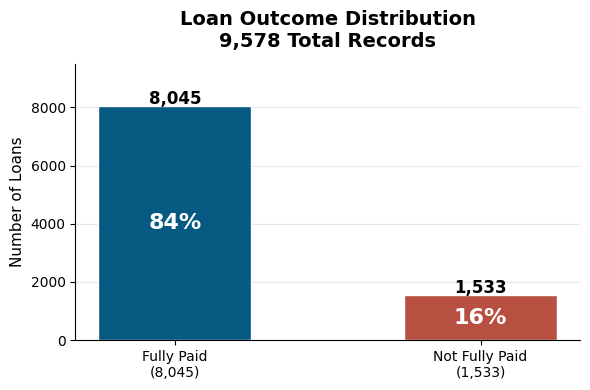

Saved: chart_imbalance.png  →  used on Slide 6


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ['Fully Paid\n(8,045)', 'Not Fully Paid\n(1,533)'],
    [counts[0], counts[1]],
    color=['#065A82', '#B85042'], width=0.5, edgecolor='white'
)

# Count labels above bars
for bar, val in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Percentage labels inside bars
ax.text(0, counts[0]/2, f'{counts[0]/len(df)*100:.0f}%',
        ha='center', va='center', fontsize=16, color='white', fontweight='bold')
ax.text(1, counts[1]/2, f'{counts[1]/len(df)*100:.0f}%',
        ha='center', va='center', fontsize=16, color='white', fontweight='bold')

ax.set_title('Loan Outcome Distribution\n9,578 Total Records',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Loans', fontsize=11)
ax.set_ylim(0, 9500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#E2E8F0')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_imbalance.png  →  used on Slide 6')


---
## Section 5 — Pearson Correlation Analysis (Slide 7: Finding 1)

### What is Pearson Correlation?
Pearson correlation measures the **linear relationship** between two numeric variables. The result is a coefficient between **-1 and +1**:
- **+1** = as one variable goes up, the other always goes up
- **-1** = as one goes up, the other always goes down
- **0** = no linear relationship

`df.corr()` computes the Pearson coefficient between every pair of columns. We extract just the column showing each feature's relationship with `Not Fully Paid`.


In [8]:
# Compute correlation matrix and extract target column
corr_matrix = df.corr()
target_corr = corr_matrix['Not Fully Paid'].drop('Not Fully Paid').sort_values()

print('Pearson Correlation with "Not Fully Paid" (sorted):')
print()
for col, val in target_corr.items():
    direction = '↑ increases default risk' if val > 0 else '↓ decreases default risk'
    print(f'  {val:+.4f}  {col:<40}  ({direction})')


Pearson Correlation with "Not Fully Paid" (sorted):

  -0.1581  Credit Policy                             (↓ decreases default risk)
  -0.1497  FICO Score                                (↓ decreases default risk)
  -0.0471  Purpose Credit Card                       (↓ decreases default risk)
  -0.0334  Log Annual Income                         (↓ decreases default risk)
  -0.0292  Days with Credit Line                     (↓ decreases default risk)
  -0.0286  Purpose Major Purchase                    (↓ decreases default risk)
  -0.0175  Purpose Debt Consolidation                (↓ decreases default risk)
  -0.0074  Annual Income                             (↓ decreases default risk)
  -0.0074  Monthly Income                            (↓ decreases default risk)
  +0.0073  Purpose Home Improvement                  (↑ increases default risk)
  +0.0089  Delinquencies 2 Years                     (↑ increases default risk)
  +0.0216  Purpose Educational                       (↑ increases d

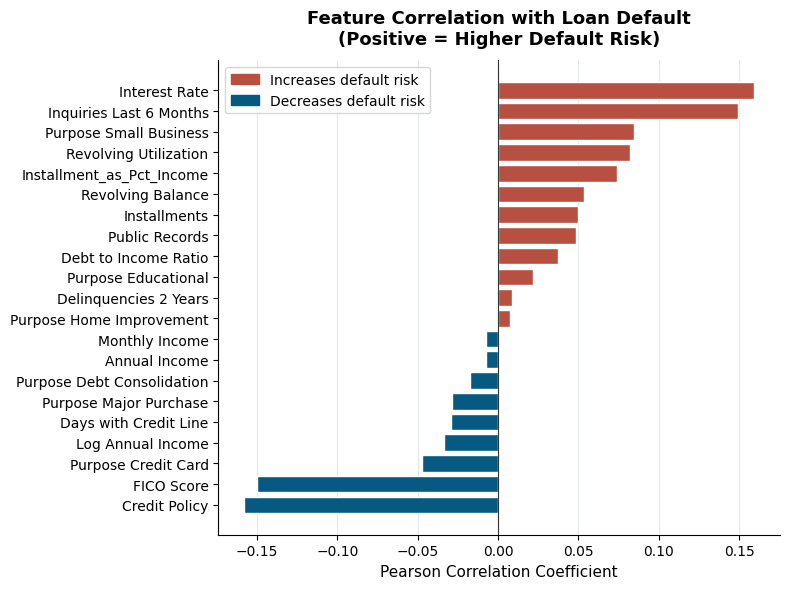

Saved: chart_correlation.png  →  used on Slide 7


In [9]:
colors = ['#B85042' if v > 0 else '#065A82' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='#333333', linewidth=0.8)

ax.set_title('Feature Correlation with Loan Default\n(Positive = Higher Default Risk)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, color='#E2E8F0')
ax.set_axisbelow(True)

red_patch  = mpatches.Patch(color='#B85042', label='Increases default risk')
blue_patch = mpatches.Patch(color='#065A82', label='Decreases default risk')
ax.legend(handles=[red_patch, blue_patch], fontsize=10)

plt.tight_layout()
plt.savefig('chart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_correlation.png  →  used on Slide 7')


---
## Section 6 — Statistical Significance Testing (Slides 8 & 9)

### Method: Independent Samples t-test + Cohen's d

An **independent samples t-test** tests whether the difference in means between two groups (defaulted vs. repaid) is statistically real or likely due to random chance.

**How the p-value is calculated — step by step:**
1. Calculate the mean of each group
2. Calculate the standard deviation of each group (spread of the data)
3. Compute the **pooled standard deviation**: `sqrt((std1² + std2²) / 2)` — combines both groups' spread
4. Compute the **t-statistic**: gap between means divided by the standard error — how many 'units of spread' apart the two group means are
5. Convert the t-statistic to a **p-value** using the t-distribution. The p-value is the probability of seeing a gap this large purely by random chance if no real difference exists

**Cohen's d (effect size):** `(mean1 - mean2) / pooled_std`  
Thresholds: small < 0.2, medium < 0.5, large < 0.8  
With large datasets, p-values can be near zero even for trivially small differences. Cohen's d tells you whether the difference is practically meaningful, not just statistically real.

> `scipy.stats.ttest_ind()` performs all steps 1–5 automatically.


### 6.1 — FICO Score (Slide 8, left chart)

In [10]:
paid    = df[df['Not Fully Paid'] == 0]
default = df[df['Not Fully Paid'] == 1]

f0 = paid['FICO Score']
f1 = default['FICO Score']

t_fico, p_fico       = stats.ttest_ind(f0, f1)
pooled_std_fico      = np.sqrt((f0.std()**2 + f1.std()**2) / 2)
cohens_d_fico        = (f0.mean() - f1.mean()) / pooled_std_fico

print('=== FICO SCORE ===')
print(f'  Fully Paid     n={len(f0):,}   mean={f0.mean():.4f}   std={f0.std():.4f}')
print(f'  Not Fully Paid n={len(f1):,}   mean={f1.mean():.4f}   std={f1.std():.4f}')
print(f'  Mean gap:          {f0.mean() - f1.mean():.4f} points')
print(f'  Pooled std:        {pooled_std_fico:.4f}')
print(f'  t-statistic:       {t_fico:.6f}')
print(f'  p-value:           {p_fico:.2e}  (= {p_fico:.20f})')
print(f"  Cohen's d:         {cohens_d_fico:.4f}")
print()
print('  Interpretation:')
print(f'  p = {p_fico:.2e} → statistically significant (p << 0.05)')
print(f"  Cohen's d = {cohens_d_fico:.2f} → small-to-medium effect")
print('  Large std values relative to the 15-pt gap explain heavy distribution overlap.')


=== FICO SCORE ===
  Fully Paid     n=8,045   mean=713.3269   std=38.2237
  Not Fully Paid n=1,533   mean=697.8284   std=33.7568
  Mean gap:          15.4985 points
  Pooled std:        36.0595
  t-statistic:       14.812744
  p-value:           4.23e-49  (= 0.00000000000000000000)
  Cohen's d:         0.4298

  Interpretation:
  p = 4.23e-49 → statistically significant (p << 0.05)
  Cohen's d = 0.43 → small-to-medium effect
  Large std values relative to the 15-pt gap explain heavy distribution overlap.


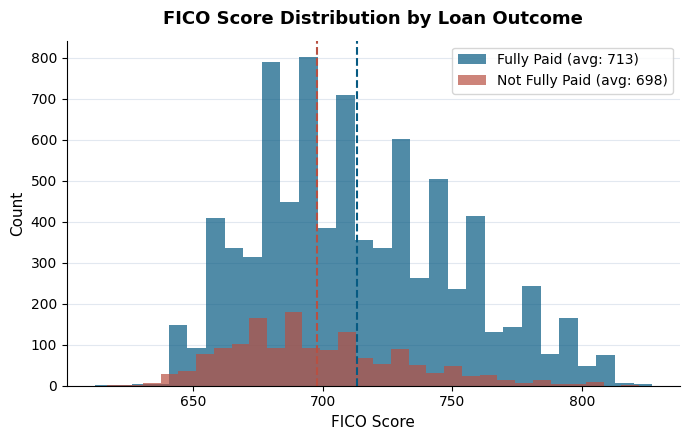

Saved: chart_fico.png  →  Slide 8, left chart


In [11]:
# FICO distribution chart — Slide 8 left
# figsize=(7, 4.5) matches the inquiries chart for visual consistency on the slide
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(f0, bins=30, alpha=0.7, color='#065A82',
        label=f'Fully Paid (avg: {f0.mean():.0f})')
ax.hist(f1, bins=30, alpha=0.7, color='#B85042',
        label=f'Not Fully Paid (avg: {f1.mean():.0f})')
ax.axvline(f0.mean(), color='#065A82', linestyle='--', linewidth=1.5)
ax.axvline(f1.mean(), color='#B85042', linestyle='--', linewidth=1.5)

ax.set_title('FICO Score Distribution by Loan Outcome',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('FICO Score', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#E2E8F0')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_fico.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_fico.png  →  Slide 8, left chart')


### 6.2 — Credit Inquiries (Slide 8, right chart)

In [12]:
q0 = paid['Inquiries Last 6 Months']
q1 = default['Inquiries Last 6 Months']

t_q, p_q        = stats.ttest_ind(q0, q1)
pooled_std_q    = np.sqrt((q0.std()**2 + q1.std()**2) / 2)
cohens_d_q      = (q1.mean() - q0.mean()) / pooled_std_q

print('=== CREDIT INQUIRIES (LAST 6 MONTHS) ===')
print(f'  Fully Paid     n={len(q0):,}   mean={q0.mean():.4f}   std={q0.std():.4f}')
print(f'  Not Fully Paid n={len(q1):,}   mean={q1.mean():.4f}   std={q1.std():.4f}')
print(f'  Mean gap:          {q1.mean() - q0.mean():.4f}')
print(f'  Pooled std:        {pooled_std_q:.4f}')
print(f'  t-statistic:       {t_q:.6f}')
print(f'  p-value:           {p_q:.2e}  (= {p_q:.20f})')
print(f"  Cohen's d:         {cohens_d_q:.4f}")
print()
print('  Threshold breakdown (% of each group at or above threshold):')
for threshold in [3, 4, 5]:
    pct_paid = (q0 >= threshold).mean() * 100
    pct_def  = (q1 >= threshold).mean() * 100
    ratio    = pct_def / pct_paid
    print(f'  {threshold}+  →  Fully Paid: {pct_paid:.1f}%  |  Not Fully Paid: {pct_def:.1f}%  |  {ratio:.1f}x more likely to default')
print()
print('  Recommendation: 4+ is the most defensible policy threshold.')
print('  Sharper signal than 3+, defaulters still >2x as likely to be in this group.')


=== CREDIT INQUIRIES (LAST 6 MONTHS) ===
  Fully Paid     n=8,045   mean=1.4339   std=1.9990
  Not Fully Paid n=1,533   mean=2.3307   std=2.9335
  Mean gap:          0.8968
  Pooled std:        2.5101
  t-statistic:       -14.791043
  p-value:           5.79e-49  (= 0.00000000000000000000)
  Cohen's d:         0.3573

  Threshold breakdown (% of each group at or above threshold):
  3+  →  Fully Paid: 19.4%  |  Not Fully Paid: 35.0%  |  1.8x more likely to default
  4+  →  Fully Paid: 10.9%  |  Not Fully Paid: 23.2%  |  2.1x more likely to default
  5+  →  Fully Paid: 6.4%  |  Not Fully Paid: 15.9%  |  2.5x more likely to default

  Recommendation: 4+ is the most defensible policy threshold.
  Sharper signal than 3+, defaulters still >2x as likely to be in this group.


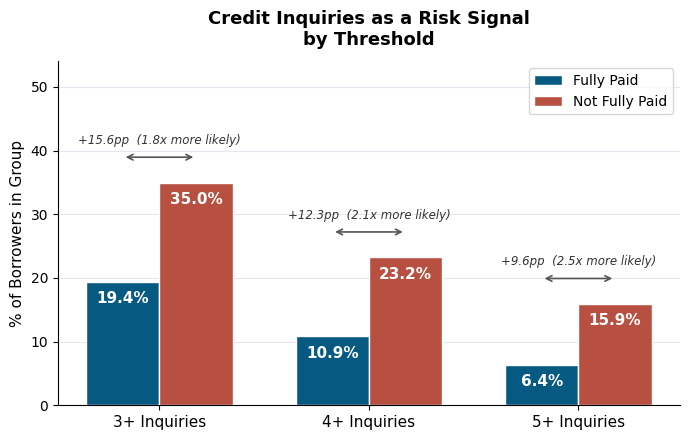

Saved: chart_inquiries.png  →  Slide 8, right chart


In [13]:
# Credit inquiries threshold chart — Slide 8 right
# figsize=(7, 4.5) to match FICO chart proportions for slide consistency
thresholds   = ['3+ Inquiries', '4+ Inquiries', '5+ Inquiries']
paid_pcts    = [(q0 >= t).mean()*100 for t in [3, 4, 5]]
default_pcts = [(q1 >= t).mean()*100 for t in [3, 4, 5]]
x     = np.arange(len(thresholds))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))

bars1 = ax.bar(x - width/2, paid_pcts,    width,
               label='Fully Paid',     color='#065A82', edgecolor='white')
bars2 = ax.bar(x + width/2, default_pcts, width,
               label='Not Fully Paid', color='#B85042', edgecolor='white')

# Value labels inside bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'{bar.get_height():.1f}%', ha='center', va='top',
            fontsize=11, fontweight='bold', color='white')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'{bar.get_height():.1f}%', ha='center', va='top',
            fontsize=11, fontweight='bold', color='white')

# Difference annotations above bars
diffs  = [d - p for p, d in zip(paid_pcts, default_pcts)]
ratios = [d / p for p, d in zip(paid_pcts, default_pcts)]
for i, (diff, ratio) in enumerate(zip(diffs, ratios)):
    bar_top = max(paid_pcts[i], default_pcts[i])
    arrow_y = bar_top + 4.0
    text_y  = arrow_y + 1.6
    ax.annotate('', xy=(x[i] + width/2, arrow_y), xytext=(x[i] - width/2, arrow_y),
                arrowprops=dict(arrowstyle='<->', color='#555555', lw=1.2))
    ax.text(x[i], text_y, f'+{diff:.1f}pp  ({ratio:.1f}x more likely)',
            ha='center', va='bottom', fontsize=8.5, color='#333333', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(thresholds, fontsize=11)
ax.set_ylabel('% of Borrowers in Group', fontsize=11)
ax.set_title('Credit Inquiries as a Risk Signal\nby Threshold',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 54)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#E2E8F0')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_inquiries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_inquiries.png  →  Slide 8, right chart')


### 6.3 — Installment as Percent of Income (Slide 9, left chart)

In [14]:
i0 = paid['Installment_as_Pct_Income'] * 100
i1 = default['Installment_as_Pct_Income'] * 100

t_inst, p_inst     = stats.ttest_ind(i0, i1)
pooled_std_inst    = np.sqrt((i0.std()**2 + i1.std()**2) / 2)
cohens_d_inst      = (i1.mean() - i0.mean()) / pooled_std_inst

print('=== INSTALLMENT AS PERCENT OF INCOME * ===')
print('(* = not in original dataset — engineered feature)')
print(f'  Fully Paid     n={len(i0):,}   mean={i0.mean():.4f}%   std={i0.std():.4f}%')
print(f'  Not Fully Paid n={len(i1):,}   mean={i1.mean():.4f}%   std={i1.std():.4f}%')
print(f'  Mean gap:          {i1.mean() - i0.mean():.4f}%')
print(f'  Pooled std:        {pooled_std_inst:.4f}')
print(f'  t-statistic:       {t_inst:.6f}')
print(f'  p-value:           {p_inst:.2e}  (= {p_inst:.20f})')
print(f"  Cohen's d:         {cohens_d_inst:.4f}")
print()
print("  Interpretation:")
print(f"  p = {p_inst:.2e} → statistically significant")
print(f"  Cohen's d = {cohens_d_inst:.2f} → TRIVIALLY SMALL effect (threshold is 0.2 for 'small')")
print("  Conclusion: the gap is real but too small to be a reliable standalone predictor.")
print("  Further data exploration required before establishing a policy threshold.")


=== INSTALLMENT AS PERCENT OF INCOME * ===
(* = not in original dataset — engineered feature)
  Fully Paid     n=8,045   mean=6.6396%   std=4.2844%
  Not Fully Paid n=1,533   mean=7.5269%   std=4.8315%
  Mean gap:          0.8873%
  Pooled std:        4.5662
  t-statistic:       -7.274883
  p-value:           3.74e-13  (= 0.00000000000037394381)
  Cohen's d:         0.1943

  Interpretation:
  p = 3.74e-13 → statistically significant
  Cohen's d = 0.19 → TRIVIALLY SMALL effect (threshold is 0.2 for 'small')
  Conclusion: the gap is real but too small to be a reliable standalone predictor.
  Further data exploration required before establishing a policy threshold.


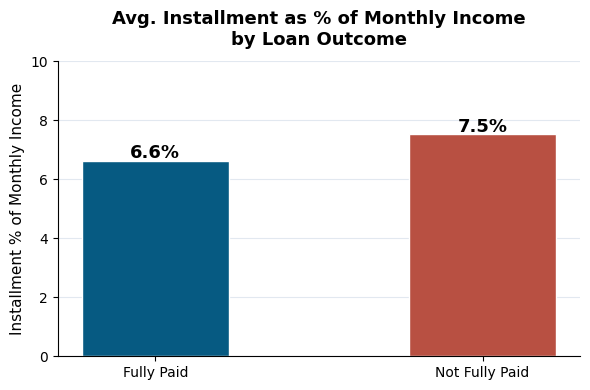

Saved: chart_installment_pct.png  →  Slide 9, left chart


In [15]:
# Installment as % of income bar chart — Slide 9 left
# Note: annotation box removed from this version for visual clarity on the slide
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ['Fully Paid', 'Not Fully Paid'],
    [i0.mean(), i1.mean()],
    color=['#065A82', '#B85042'], width=0.45, edgecolor='white'
)

for bar, v in zip(bars, [i0.mean(), i1.mean()]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

ax.set_title('Avg. Installment as % of Monthly Income\nby Loan Outcome',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Installment % of Monthly Income', fontsize=11)
ax.set_ylim(0, 10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#E2E8F0')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_installment_pct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_installment_pct.png  →  Slide 9, left chart')


---
## Section 7 — Loan Purpose Default Rates (Slide 9, right chart)

Each loan purpose was one-hot encoded as a binary column during data cleaning. This analysis calculates the default rate within each purpose category and compares it to the overall platform average of 16%.


In [16]:
# Calculate default rate for each loan purpose
purpose_cols = [c for c in df.columns if c.startswith('Purpose')]
purpose_rates = {}
for col in purpose_cols:
    subset = df[df[col] == 1]
    if len(subset) > 0:
        label = col.replace('Purpose ', '')
        purpose_rates[label] = subset['Not Fully Paid'].mean() * 100

purpose_rates['Overall Average'] = df['Not Fully Paid'].mean() * 100
purpose_df = pd.Series(purpose_rates).sort_values(ascending=True)

print('Default Rate by Loan Purpose:')
for purpose, rate in purpose_df.items():
    marker = ' ← platform average' if purpose == 'Overall Average' else ''
    print(f'  {purpose:<30} {rate:.1f}%{marker}')


Default Rate by Loan Purpose:
  Major Purchase                 11.2%
  Credit Card                    11.6%
  Debt Consolidation             15.2%
  Overall Average                16.0% ← platform average
  Home Improvement               17.0%
  Educational                    20.1%
  Small Business                 27.8%


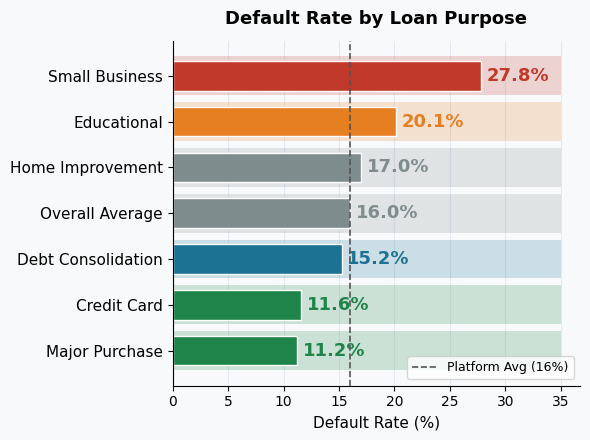

Saved: chart_purpose.png  →  Slide 9, right chart


In [17]:
# Loan purpose chart with color gradient — Slide 9 right
# Color coding: red = highest risk, orange = elevated, gray = average,
#               teal = below average, green = lowest risk
purposes = list(purpose_df.index)
rates     = list(purpose_df.values)

def rate_to_color(r):
    if r >= 25:   return '#C0392B'
    elif r >= 20: return '#E67E22'
    elif r >= 16: return '#7F8C8D'
    elif r >= 14: return '#1C7293'
    else:         return '#1E8449'

bar_colors = [rate_to_color(r) for r in rates]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

for i, (purpose, rate, bc) in enumerate(zip(purposes, rates, bar_colors)):
    ax.barh(i, 35, height=0.85, color=bc+'33', left=0, zorder=1)  # tinted row bg
    ax.barh(i, rate, height=0.65, color=bc, zorder=2, edgecolor='white')
    ax.text(rate + 0.5, i, f'{rate:.1f}%', va='center',
            fontsize=13, fontweight='bold', color=bc, zorder=3)

ax.set_yticks(range(len(purposes)))
ax.set_yticklabels(purposes, fontsize=11)
ax.set_xlabel('Default Rate (%)', fontsize=11)
ax.set_title('Default Rate by Loan Purpose', fontsize=13, fontweight='bold', pad=12)
ax.axvline(df['Not Fully Paid'].mean()*100, color='#555555', linewidth=1.2,
           linestyle='--', label='Platform Avg (16%)', zorder=4)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, color='#E2E8F0', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_purpose.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_purpose.png  →  Slide 9, right chart')


---
## Section 8 — Predictive Modeling (Slides 10 & 11)

### Pipeline overview:
1. **Oversample** the minority class (defaulted loans) to fix class imbalance
2. **Split** the balanced dataset 80/20 into training and test sets
3. **Scale** features using StandardScaler (fit on training data only)
4. **Train** a Logistic Regression model
5. **Evaluate** on the held-out test set


### 8.1 — Handle Class Imbalance via Oversampling

In [18]:
# Separate into majority (repaid) and minority (defaulted) groups
majority    = df[df['Not Fully Paid'] == 0]
minority    = df[df['Not Fully Paid'] == 1]

print(f'Before balancing:')
print(f'  Majority (repaid):  {len(majority):,}')
print(f'  Minority (default): {len(minority):,}')

# Oversample minority to match majority size
# replace=True allows duplicate rows (sampling with replacement)
# random_state=42 ensures reproducible results
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

df_balanced = pd.concat([majority, minority_upsampled])

print(f'\nAfter balancing:')
print(df_balanced['Not Fully Paid'].value_counts())
print(f'Total records: {len(df_balanced):,}')


Before balancing:
  Majority (repaid):  8,045
  Minority (default): 1,533

After balancing:
Not Fully Paid
0    8045
1    8045
Name: count, dtype: int64
Total records: 16,090


### 8.2 — Train/Test Split & Feature Scaling

In [19]:
X = df_balanced.drop('Not Fully Paid', axis=1)
y = df_balanced['Not Fully Paid']

# 80% training, 20% test — random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train):,} records')
print(f'Test set:     {len(X_test):,} records')

# StandardScaler: rescales each feature to mean=0, std=1
# CRITICAL: fit ONLY on training data to prevent data leakage
# Apply the same learned scale to test data using .transform() only
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)   # learns scale from training data
X_test_s   = scaler.transform(X_test)        # applies same scale — no re-fitting

print(f'\nScaling complete.')
print(f'Training feature means (should be ~0): {X_train_s.mean(axis=0)[:3].round(4)}')
print(f'Training feature stds  (should be ~1): {X_train_s.std(axis=0)[:3].round(4)}')


Training set: 12,872 records
Test set:     3,218 records

Scaling complete.
Training feature means (should be ~0): [ 0. -0.  0.]
Training feature stds  (should be ~1): [1. 1. 1.]


### 8.3 — Train Logistic Regression Model

In [20]:
# class_weight='balanced' adds a second layer of imbalance protection
# max_iter=1000 gives the solver enough iterations to converge
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)

print('Model trained successfully.')
print()
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred,
                             target_names=['Fully Paid', 'Not Fully Paid']))


Model trained successfully.

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

    Fully Paid       0.61      0.64      0.62      1578
Not Fully Paid       0.64      0.61      0.62      1640

      accuracy                           0.62      3218
     macro avg       0.62      0.62      0.62      3218
  weighted avg       0.62      0.62      0.62      3218



### 8.4 — Confusion Matrix (Slide 10)

In [21]:
cm = confusion_matrix(y_test, y_pred)

print('Confusion Matrix:')
print(f'  True Negatives  (correctly predicted repaid):    {cm[0,0]:,}')
print(f'  False Positives (predicted default, was repaid): {cm[0,1]:,}')
print(f'  False Negatives (predicted repaid, was default): {cm[1,0]:,}')
print(f'  True Positives  (correctly predicted default):   {cm[1,1]:,}')
print()
print(f'  Overall Accuracy: {(cm[0,0]+cm[1,1])/cm.sum()*100:.1f}%')
print(f'  Default Recall:   {cm[1,1]/(cm[1,0]+cm[1,1])*100:.1f}%  (defaults correctly caught)')
print(f'  Default Precision:{cm[1,1]/(cm[0,1]+cm[1,1])*100:.1f}%')
print()
print('  Context: a model always predicting "repaid" would score 84% accuracy')
print('  but catch 0% of defaults. 62% is only 12pp above random chance (50%).')
print('  This model needs further development and additional variables before')
print('  it would be suitable for real-world deployment.')


Confusion Matrix:
  True Negatives  (correctly predicted repaid):    1,009
  False Positives (predicted default, was repaid): 569
  False Negatives (predicted repaid, was default): 647
  True Positives  (correctly predicted default):   993

  Overall Accuracy: 62.2%
  Default Recall:   60.5%  (defaults correctly caught)
  Default Precision:63.6%

  Context: a model always predicting "repaid" would score 84% accuracy
  but catch 0% of defaults. 62% is only 12pp above random chance (50%).
  This model needs further development and additional variables before
  it would be suitable for real-world deployment.


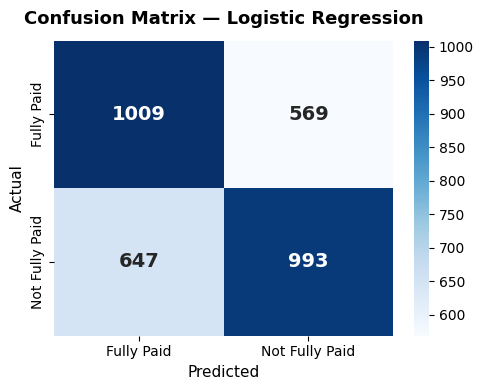

Saved: chart_confusion.png  →  Slide 10


In [22]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Fully Paid', 'Not Fully Paid'],
    yticklabels=['Fully Paid', 'Not Fully Paid'],
    ax=ax, annot_kws={'size': 14, 'weight': 'bold'}
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix — Logistic Regression',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('chart_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_confusion.png  →  Slide 10')


### 8.5 — Model Coefficients vs. Correlation Analysis (Slide 11)

In [23]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()

print('=== MODEL COEFFICIENTS (sorted, lowest to highest) ===')
print()
for feature, coef in coefs.items():
    direction = 'increases default probability' if coef > 0 else 'decreases default probability'
    print(f'  {coef:+.4f}  {feature:<40} ({direction})')

print()
print('=== NOTABLE SHIFTS: CORRELATION → MODEL ===')
print()
print('  RISK SIGNALS:')
print('  Correlation rank #1: Interest Rate             (+0.160 correlation)')
print(f'  Model rank #1:       Inquiries Last 6 Months  (coef = {coefs["Inquiries Last 6 Months"]:+.4f})')
print('  → Inquiries became the strongest default predictor once model controls for all variables')
print()
print('  PROTECTIVE SIGNALS:')
print('  Correlation rank #1: FICO Score              (-0.150 correlation)')
print(f'  Model:               FICO Score              (coef = {coefs["FICO Score"]:+.4f})')
print(f'  Model:               Log Annual Income       (coef = {coefs["Log Annual Income"]:+.4f})')
print('  → Log Annual Income emerged as nearly equally important to FICO in the model')


=== MODEL COEFFICIENTS (sorted, lowest to highest) ===

  -0.3428  Log Annual Income                        (decreases default probability)
  -0.3360  FICO Score                               (decreases default probability)
  -0.1926  Purpose Credit Card                      (decreases default probability)
  -0.1526  Purpose Debt Consolidation               (decreases default probability)
  -0.1186  Credit Policy                            (decreases default probability)
  -0.0727  Delinquencies 2 Years                    (decreases default probability)
  -0.0491  Purpose Major Purchase                   (decreases default probability)
  +0.0047  Purpose Educational                      (increases default probability)
  +0.0061  Debt to Income Ratio                     (increases default probability)
  +0.0179  Purpose Home Improvement                 (increases default probability)
  +0.0359  Revolving Utilization                    (increases default probability)
  +0.0496  Monthly I

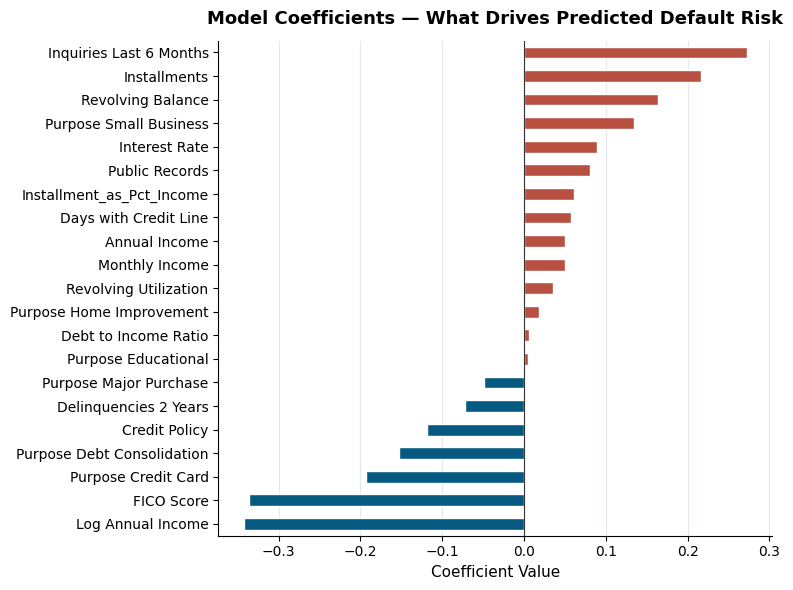

Saved: chart_coef.png  →  Slide 11


In [24]:
colors = ['#B85042' if v > 0 else '#065A82' for v in coefs.values]

fig, ax = plt.subplots(figsize=(8, 6))
coefs.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='#333333', linewidth=0.8)

ax.set_title('Model Coefficients — What Drives Predicted Default Risk',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, color='#E2E8F0')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_coef.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_coef.png  →  Slide 11')


---
## Section 9 — Full Statistical Summary

Summary of all statistical tests performed and the actual p-values found.


In [25]:
print('=== STATISTICAL SIGNIFICANCE SUMMARY ===')
print()
print(f'{"Variable":<40} {"t-stat":>10} {"p-value":>14} {"Cohen d":>10}  Conclusion')
print('-' * 100)

results = [
    ('FICO Score',                      t_fico,  p_fico,  cohens_d_fico,  'Sig. — small-medium effect. Distributions overlap heavily.'),
    ('Installment as Pct Income *',      t_inst,  p_inst,  cohens_d_inst,  'Sig. — TRIVIALLY small effect. Not reliable standalone.'),
    ('Credit Inquiries (Last 6 Mo.)',    t_q,     p_q,     cohens_d_q,     'Sig. — small effect. 4+ threshold recommended.'),
]

for name, t, p, d, note in results:
    print(f'{name:<40} {t:>10.4f} {p:>14.2e} {d:>10.4f}  {note}')

print()
print('* = not in original dataset — engineered feature')
print()
print('Key reminder: with n=9,578 records, even trivially small differences')
print('produce near-zero p-values. Always report effect size alongside p-value.')


=== STATISTICAL SIGNIFICANCE SUMMARY ===

Variable                                     t-stat        p-value    Cohen d  Conclusion
----------------------------------------------------------------------------------------------------
FICO Score                                  14.8127       4.23e-49     0.4298  Sig. — small-medium effect. Distributions overlap heavily.
Installment as Pct Income *                 -7.2749       3.74e-13     0.1943  Sig. — TRIVIALLY small effect. Not reliable standalone.
Credit Inquiries (Last 6 Mo.)              -14.7910       5.79e-49     0.3573  Sig. — small effect. 4+ threshold recommended.

* = not in original dataset — engineered feature

Key reminder: with n=9,578 records, even trivially small differences
produce near-zero p-values. Always report effect size alongside p-value.


---
## Section 10 — Chart File Index

| File | Used On | Description |
|---|---|---|
| `chart_imbalance.png` | Slide 6 | Loan outcome class distribution bar chart |
| `chart_correlation.png` | Slide 7 | Pearson correlation with default target |
| `chart_fico.png` | Slide 8 (left) | FICO score overlapping histograms by outcome |
| `chart_inquiries.png` | Slide 8 (right) | Credit inquiry threshold grouped bar chart |
| `chart_installment_pct.png` | Slide 9 (left) | Avg. installment as % of income by outcome |
| `chart_purpose.png` | Slide 9 (right) | Default rate by loan purpose with gradient coloring |
| `chart_confusion.png` | Slide 10 | Confusion matrix heatmap |
| `chart_coef.png` | Slide 11 | Logistic regression coefficients bar chart |
